In [85]:
from __future__ import annotations

import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.inspection import permutation_importance

import joblib

randomstate = 42
np.random.seed(randomstate)

artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)
figures_dir = Path('artifacts/figures')
figures_dir.mkdir(parents=True, exist_ok=True)
# 
# print('artifacts dir:', artifacts_dir.resolve())
# print('figures dir:', figures_dir.resolve())


In [86]:
df = pd.read_csv('data/S06-hw-dataset-04.csv')

In [87]:
df.shape

(25000, 62)

In [88]:
df.head()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f52,f53,f54,f55,f56,f57,f58,f59,f60,target
0,1,-1.250210,1.423474,-0.225004,-4.023138,-0.832729,-0.550874,1.772090,2.761690,-0.698750,...,10.938269,0.501178,1.600001,0.314212,1.209735,1.355697,-5.338924,1.153944,-0.153934,0
1,2,0.074328,0.376429,0.212831,-0.502074,2.017405,0.625496,1.943785,1.242030,-0.524090,...,7.775262,-4.550195,6.272586,-0.932162,-0.228543,1.735220,-3.827828,0.292165,0.273720,0
2,3,0.638481,0.060968,0.746760,2.479653,-0.292858,-0.078139,-2.918423,-0.013186,1.009135,...,-4.448447,-9.593179,-3.093519,0.029321,0.605511,0.829103,-0.085985,2.891408,0.766221,0
3,4,1.712916,-1.350969,-0.256473,1.622074,-0.445141,0.911932,-3.440345,1.505192,-1.104348,...,-1.619072,-3.237479,-5.474038,-1.582475,0.198137,3.823409,0.880395,1.148610,0.136732,0
4,5,0.905676,-0.206545,-0.068806,4.086026,-1.010045,-0.772644,-4.207688,2.506104,1.589143,...,-2.396844,-10.540129,-5.532811,-1.231203,0.000119,4.298572,-1.558235,0.924673,0.111668,0


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 62 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      25000 non-null  int64  
 1   f01     25000 non-null  float64
 2   f02     25000 non-null  float64
 3   f03     25000 non-null  float64
 4   f04     25000 non-null  float64
 5   f05     25000 non-null  float64
 6   f06     25000 non-null  float64
 7   f07     25000 non-null  float64
 8   f08     25000 non-null  float64
 9   f09     25000 non-null  float64
 10  f10     25000 non-null  float64
 11  f11     25000 non-null  float64
 12  f12     25000 non-null  float64
 13  f13     25000 non-null  float64
 14  f14     25000 non-null  float64
 15  f15     25000 non-null  float64
 16  f16     25000 non-null  float64
 17  f17     25000 non-null  float64
 18  f18     25000 non-null  float64
 19  f19     25000 non-null  float64
 20  f20     25000 non-null  float64
 21  f21     25000 non-null  float64
 22

In [90]:
df.describe()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f52,f53,f54,f55,f56,f57,f58,f59,f60,target
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000
mean,12500.500000,-0.000386,-0.004872,0.003202,0.335329,-0.000563,-0.010118,0.001182,0.957385,-0.004658,...,-0.166251,-3.387506,1.749793,-0.013017,-0.001383,0.893365,-0.909479,0.000570,-0.000754,0.04920
std,7217.022701,1.001623,0.995606,1.004367,3.207537,0.993965,1.002172,2.432162,1.830223,1.013470,...,4.234741,4.331576,5.318660,1.001594,0.996409,2.445185,1.962618,0.994320,0.997167,0.21629
min,1.000000,-4.370993,-4.087073,-4.103875,-13.249937,-4.118778,-3.895974,-8.883224,-8.132548,-4.068933,...,-20.021141,-18.332290,-20.336666,-4.349216,-4.119472,-9.508509,-7.919287,-4.038312,-3.812255,0.00000
25%,6250.750000,-0.680165,-0.675100,-0.675426,-1.750048,-0.669764,-0.674374,-1.647977,-0.217260,-0.688278,...,-2.897904,-6.278403,-1.775889,-0.689962,-0.676191,-0.735473,-2.226959,-0.666367,-0.665861,0.00000
50%,12500.500000,0.001859,-0.000247,0.013272,0.403483,-0.001309,-0.005994,-0.011349,0.963009,0.000414,...,-0.396946,-3.462072,1.931851,-0.020933,-0.004193,0.888535,-0.923354,0.004381,0.002420,0.00000
75%,18750.250000,0.679702,0.659523,0.683437,2.486453,0.672299,0.652629,1.658680,2.167758,0.681040,...,2.344956,-0.578540,5.473886,0.661300,0.673722,2.516790,0.395648,0.666474,0.665918,0.00000
max,25000.000000,4.208888,3.984564,3.793442,15.288250,4.020733,4.279607,9.538525,9.321099,4.261349,...,20.717964,18.818764,20.688069,4.338337,3.902131,11.880651,6.778980,3.834922,4.012639,1.00000


In [91]:
y = df['target']
y.value_counts(normalize=True).to_frame('fraction')

,fraction
target,
0,0.9508
1,0.0492


In [92]:
has_na = 0
for i in df.columns:
    if df[i].isna().mean() != 0:
        print(i, df[i].isna().mean())
        has_na = 1
if has_na == 0:
    print('Нет пропусков')

Нет пропусков


In [93]:
X = df.drop(['id', 'target'], axis=1)
feature_names = list(X.columns)
X

,f01,f02,f03,f04,f05,f06,f07,f08,f09,f10,...,f51,f52,f53,f54,f55,f56,f57,f58,f59,f60
0,-1.250210,1.423474,-0.225004,-4.023138,-0.832729,-0.550874,1.772090,2.761690,-0.698750,-1.857165,...,1.130519,10.938269,0.501178,1.600001,0.314212,1.209735,1.355697,-5.338924,1.153944,-0.153934
1,0.074328,0.376429,0.212831,-0.502074,2.017405,0.625496,1.943785,1.242030,-0.524090,-0.009307,...,-0.311057,7.775262,-4.550195,6.272586,-0.932162,-0.228543,1.735220,-3.827828,0.292165,0.273720
2,0.638481,0.060968,0.746760,2.479653,-0.292858,-0.078139,-2.918423,-0.013186,1.009135,-4.966481,...,-1.159370,-4.448447,-9.593179,-3.093519,0.029321,0.605511,0.829103,-0.085985,2.891408,0.766221
3,1.712916,-1.350969,-0.256473,1.622074,-0.445141,0.911932,-3.440345,1.505192,-1.104348,0.291916,...,0.662697,-1.619072,-3.237479,-5.474038,-1.582475,0.198137,3.823409,0.880395,1.148610,0.136732
4,0.905676,-0.206545,-0.068806,4.086026,-1.010045,-0.772644,-4.207688,2.506104,1.589143,-0.849466,...,1.245923,-2.396844,-10.540129,-5.532811,-1.231203,0.000119,4.298572,-1.558235,0.924673,0.111668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,0.365760,0.415970,-2.011062,-5.371130,-1.308558,-0.563970,5.201922,-3.499144,-0.060352,6.305022,...,-0.801519,-1.929263,-8.680673,15.047120,-0.143813,0.516291,0.823833,-4.224887,-1.587583,0.771520
24996,-0.149945,0.333374,0.376841,1.034450,-0.675257,-0.918264,-0.852997,0.807168,0.608834,-1.938881,...,-1.633939,-2.703597,-7.164746,3.283665,-0.992620,-0.238159,0.529495,-2.853572,0.095721,0.187521
24997,1.126695,-0.337465,-0.025865,1.120373,0.926596,1.376231,-1.477048,1.198022,-0.127361,-6.842055,...,0.779228,-3.340906,-12.411586,4.887072,2.282438,-0.802952,3.094978,-5.014264,-0.580568,-0.226469
24998,0.573838,-0.546452,-1.155111,4.362236,0.179052,0.842566,0.755143,0.002815,0.015477,1.724121,...,-0.111896,-4.822115,-10.745787,3.098257,-1.255395,0.186830,3.303343,2.933538,0.585642,-0.989008


In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=randomstate, stratify=y)

In [95]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=randomstate)

results = []
best_models = {}
search_summaries = {}

In [96]:
def compute_metrics(y_true, y_pred, y_proba=None) -> dict:
    m = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred)),
    }
    if y_proba is not None:
        try:
            m["roc_auc"] = float(roc_auc_score(y_true, y_proba))
        except Exception:
            m["roc_auc"] = None
    else:
        m["roc_auc"] = None
    return m

def evaluate_on_test(model, X_test, y_test, label: str) -> dict:
    pred = model.predict(X_test)
    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    metrics = compute_metrics(y_test, pred, proba)
    metrics["model"] = label
    return metrics

def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('w') as f:
        json.dump(obj, f, ensure_ascii=False, indent=4)
        
def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    
    log_cm = np.log1p(cm)
    
    plt.figure(figsize=(5,4))
    plt.imshow(log_cm, cmap="plasma", interpolation="nearest")
    plt.title(title)
    plt.xlabel("pred")
    plt.ylabel("true")
    plt.xticks([0,1])
    plt.yticks([0,1])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j,i,str(v), ha="center", va="center")
    plt.savefig(f"artifacts/figures/{title}.png")
    plt.show()
    
def plot_roc(model, X_test, y_test, title: str):
    if not hasattr(model, "predict_proba"):
        print("ROC: модель не поддерживает predict_proba")
        return
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    plt.savefig(f"artifacts/figures/{title}.png")
    plt.show()
    
def plot_pr(model, X_test, y_test, title: str):
    if not hasattr(model, "predict_proba"):
        print("PR: модель не поддерживает predict_proba")
        return
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    plt.savefig(f"artifacts/figures/{title}.png")
    plt.show()
    
def run_search(label: str, estimator, param_grid: dict):
    search = GridSearchCV(
        estimator,
        param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True
    )
    search.fit(X_train, y_train)
    
    best = search.best_estimator_
    best_models[label] = best
    search_summaries[label] = {
        "best_params": search.best_params_,
        "best_cv_roc_auc": search.best_score_,
    }
    results.append(evaluate_on_test(best, X_test, y_test, label))
    return search

Фиксированный seed важен для воспроизводимости эксперимента, стратификация нужна чтобы обучающая и тестовая выборки были аналогичны изначальному набору данных.

In [97]:


dummy = DummyClassifier(strategy="most_frequent")

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=4000, random_state=randomstate))
])

lr_grid = {
    "lr__C": [0.001, 0.01, 0.1, 1, 10],
    "lr__penalty": ["l2"],
    "lr__solver": ["lbfgs"]
}

lr_search = GridSearchCV(
    lr, lr_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)
lr_search.fit(X_train, y_train)

dummy.fit(X_train, y_train)

results.append(evaluate_on_test(dummy, X_test, y_test, "Dummy"))

best_models["Dummy"] = dummy


best_lr = lr_search.best_estimator_
best_models["LogisticRegression"] = best_lr

search_summaries["LogisticRegression"] = {
    "best_params": lr_search.best_params_,
    "best_cv_roc_auc": float(lr_search.best_score_),
}

results.append(evaluate_on_test(best_lr, X_test, y_test, "LogisticRegression"))

display(search_summaries["LogisticRegression"])

display(results)

D:\konst\PycharmProjects\mirea_real\AIE_DPO\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


{'best_params': {'lr__C': 0.001, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'},
 'best_cv_roc_auc': 0.8287419831906675}

[{'accuracy': 0.95088, 'f1': 0.0, 'roc_auc': 0.5, 'model': 'Dummy'},
 {'accuracy': 0.95312,
  'f1': 0.09287925696594428,
  'roc_auc': 0.8471910949898083,
  'model': 'LogisticRegression'}]

Dummy всегда предсказывает самый частый класс, поэтому accuracy примерно равна доле этого класса в данных. f1 для положительного класса равен 0, то есть модель полностью игнорирует редкий класс. roc-auc = 0.5, что соответствует модели, не различающей положительные и отрицательные объекты (константный выход).

Логистическая регрессия даёт accuracy немного выше, чем dummy, и F1 остаётся низким — модель по-прежнему плохо находит редкий класс. При этом ROC-AUC значительно выше 0.5, что показывает: по вероятностям модель умеет различать положительный и отрицательный классы и работает лучше случайного угадывания.

In [98]:
dt = DecisionTreeClassifier(
    random_state=randomstate,
    max_depth=10,
    min_samples_leaf=5,
    ccp_alpha=0.0
)

dt_grid = {
    "max_depth": [5, 10, 15],
    "min_samples_leaf": [3, 4, 5, 7],
    "ccp_alpha": [0, 0.001, 0.01, 0.1],
}

dt_search = run_search("DecisionTree", dt, dt_grid)
search_summaries["DecisionTree"]

{'best_params': {'ccp_alpha': 0, 'max_depth': 10, 'min_samples_leaf': 5},
 'best_cv_roc_auc': np.float64(0.7889001510725856)}

In [99]:
rf = RandomForestClassifier(
    n_estimators=100, 
    random_state=randomstate,
    n_jobs=-1,
    oob_score=False,
)

rf_grid = {
    "max_depth": [7, 10],
    "min_samples_leaf": [3, 5],
    "max_features": ["sqrt", 0.5],
}

rf_search = run_search("RandomForest", rf, rf_grid)
search_summaries["RandomForest"]

{'best_params': {'max_depth': 10,
  'max_features': 'sqrt',
  'min_samples_leaf': 5},
 'best_cv_roc_auc': np.float64(0.8811488963987173)}

In [100]:
hgb = HistGradientBoostingClassifier(
    random_state=randomstate,
    early_stopping=True,
)

hgb_grid = {
    "learning_rate": [0.05, 0.1, 0.15],
    "max_depth": [2, 3, 5],
    "max_leaf_nodes": [7, 15, 20]
}

hgb_search = run_search("Boosting", hgb, hgb_grid)
search_summaries["Boosting"]

D:\konst\PycharmProjects\mirea_real\AIE_DPO\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'best_params': {'learning_rate': 0.1, 'max_depth': 3, 'max_leaf_nodes': 15},
 'best_cv_roc_auc': np.float64(0.895120022359691)}

In [101]:
estimators = [
    ("dt", best_models["DecisionTree"]),
    ("rf", best_models["RandomForest"]),
    ("hgb", best_models["Boosting"]),
]

stack = StackingClassifier(
    estimators = estimators,
    final_estimator = LogisticRegression(max_iter=3000, random_state=randomstate),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

stack.fit(X_train, y_train)
best_models["Stacking"] = stack
results.append(evaluate_on_test(stack, X_test, y_test, "Stacking"))



In [102]:
df = pd.DataFrame(results)

df_sorted = df.copy()
df_sorted = df_sorted.sort_values(["roc_auc", "accuracy"], ascending=False)

df_sorted



,accuracy,f1,roc_auc,model
4,0.97744,0.706861,0.906617,Boosting
5,0.97952,0.751938,0.904335,Stacking
3,0.96736,0.502439,0.897232,RandomForest
1,0.95312,0.092879,0.847191,LogisticRegression
2,0.96736,0.573222,0.777499,DecisionTree
0,0.95088,0.000000,0.500000,Dummy


In [103]:
print(df_sorted.to_markdown(index=False))

|   accuracy |        f1 |   roc_auc | model              |
|-----------:|----------:|----------:|:-------------------|
|    0.97744 | 0.706861  |  0.906617 | Boosting           |
|    0.97952 | 0.751938  |  0.904335 | Stacking           |
|    0.96736 | 0.502439  |  0.897232 | RandomForest       |
|    0.95312 | 0.0928793 |  0.847191 | LogisticRegression |
|    0.96736 | 0.573222  |  0.777499 | DecisionTree       |
|    0.95088 | 0         |  0.5      | Dummy              |


Boosting - лучшая модель по roc_auc

In [104]:

best_label = df_sorted.iloc[0]["model"]
best_model = best_models[best_label]

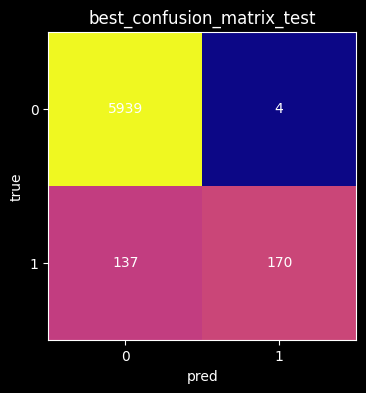

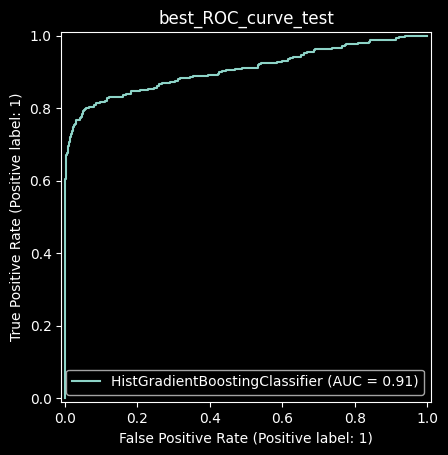

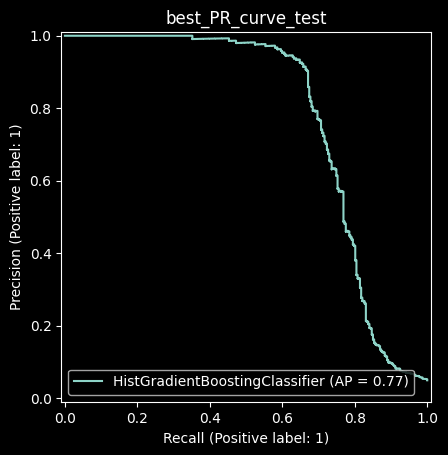

In [105]:
y_pred = best_model.predict(X_test)
plot_confusion(y_test, y_pred, title="best_confusion_matrix_test")
plot_roc(best_model, X_test, y_test, title="best_ROC_curve_test")
plot_pr(best_model, X_test, y_test, title="best_PR_curve_test")

In [106]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["True 0", "True 1"],
    columns=["Pred 0", "Pred 1"]
)

print(cm_df.to_markdown())

|        |   Pred 0 |   Pred 1 |
|:-------|---------:|---------:|
| True 0 |     5939 |        4 |
| True 1 |      137 |      170 |


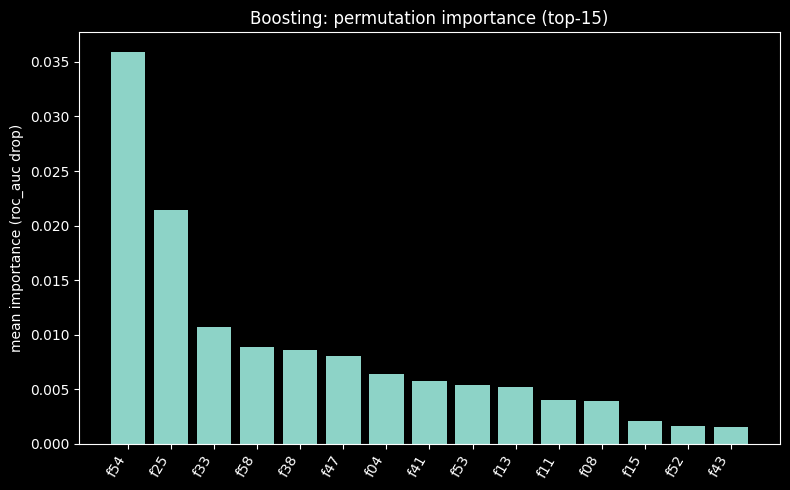

In [107]:
scoring = "roc_auc"

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=randomstate,
    scoring=scoring
)

imp = perm.importances_mean
idx = np.argsort(imp)[::-1][:15]

plt.figure(figsize=(8, 5))
plt.bar(range(len(idx)), imp[idx])
plt.xticks(range(len(idx)), [feature_names[i] for i in idx], rotation=60, ha="right")
plt.ylabel(f"mean importance ({scoring} drop)")
plt.title(f"{best_label}: permutation importance (top-15)")
plt.tight_layout()
plt.savefig("artifacts/figures/best_model_perm_imp.png")
plt.show()

Признаки f54 и f25 влияют на roc_auc больше всех, влияние остальных намного меньше и постепенно уменьшается.

In [108]:

imp_df = pd.DataFrame(
    imp[idx],
    index=[feature_names[i] for i in idx],
    columns=["roc_auc_drop"]
)

print(imp_df.to_markdown())

|     |   roc_auc_drop |
|:----|---------------:|
| f54 |     0.0359234  |
| f25 |     0.0214444  |
| f33 |     0.0106586  |
| f58 |     0.00887634 |
| f38 |     0.00857462 |
| f47 |     0.00805217 |
| f04 |     0.00634919 |
| f41 |     0.00572842 |
| f53 |     0.00539731 |
| f13 |     0.0052217  |
| f11 |     0.00396086 |
| f08 |     0.00387437 |
| f15 |     0.00209822 |
| f52 |     0.00157051 |
| f43 |     0.00148051 |


In [115]:
# data = {
#     "metrics": results
# }

data = {}

for i in results:
    data[i['model']] = {'accuracy': i['accuracy'], 'f1': i['f1'], 'roc_auc': i['roc_auc']}

display(results)
display(data)

[{'accuracy': 0.95088, 'f1': 0.0, 'roc_auc': 0.5, 'model': 'Dummy'},
 {'accuracy': 0.95312,
  'f1': 0.09287925696594428,
  'roc_auc': 0.8471910949898083,
  'model': 'LogisticRegression'},
 {'accuracy': 0.96736,
  'f1': 0.5732217573221757,
  'roc_auc': 0.7774988887372491,
  'model': 'DecisionTree'},
 {'accuracy': 0.96736,
  'f1': 0.5024390243902439,
  'roc_auc': 0.8972321747151687,
  'model': 'RandomForest'},
 {'accuracy': 0.97744,
  'f1': 0.7068607068607069,
  'roc_auc': 0.9066166584726455,
  'model': 'Boosting'},
 {'accuracy': 0.97952,
  'f1': 0.751937984496124,
  'roc_auc': 0.904334938703788,
  'model': 'Stacking'}]

{'Dummy': {'accuracy': 0.95088, 'f1': 0.0, 'roc_auc': 0.5},
 'LogisticRegression': {'accuracy': 0.95312,
  'f1': 0.09287925696594428,
  'roc_auc': 0.8471910949898083},
 'DecisionTree': {'accuracy': 0.96736,
  'f1': 0.5732217573221757,
  'roc_auc': 0.7774988887372491},
 'RandomForest': {'accuracy': 0.96736,
  'f1': 0.5024390243902439,
  'roc_auc': 0.8972321747151687},
 'Boosting': {'accuracy': 0.97744,
  'f1': 0.7068607068607069,
  'roc_auc': 0.9066166584726455},
 'Stacking': {'accuracy': 0.97952,
  'f1': 0.751937984496124,
  'roc_auc': 0.904334938703788}}

In [116]:
save_json(data, artifacts_dir / "metrics_test.json")
save_json(search_summaries, artifacts_dir / "search_summaries.json")



In [117]:
model_path = artifacts_dir / "best_model.joblib"
joblib.dump(best_model, model_path)



meta = {
    "best_model_label": best_label,
    "test_metrics": df_sorted.iloc[0].to_dict(),
    "search_summary": search_summaries.get(best_label, None),
    "random_state": randomstate,
}

save_json(meta, artifacts_dir / "best_model_meta.json")